# Baseline Model Sonuçlarının Analizi

Bu notebook'ta SEED-SD veri seti üzerinde eğitilen baseline modellerin sonuçları analiz edilmektedir.

Amaç:

- Logistic Regression ve Random Forest modellerini karşılaştırmak
- Fold bazında performans değişimini incelemek
- Duygu sınıfları arasındaki karışıklıkları analiz etmek
- ReLF modeline geçmeden önce referans performans oluşturmak

In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\ReLF


In [1]:
import pandas as pd

## Logistic Regression Sonuçları

İlk baseline model olarak Logistic Regression seçilmiştir.

Bu model doğrusal bir sınıflandırıcıdır ve veri içerisindeki lineer ilişkileri öğrenmeye çalışır.

Amaç, veri setinin ne kadarının basit doğrusal sınırlarla ayrılabildiğini görmek ve daha karmaşık modeller için referans performans oluşturmaktır.

In [2]:
logistic_df = pd.read_csv(
    "D:/ReLF/reports/baselines/logistic_regression_subject_dependent_subset.csv"
)

rf_df = pd.read_csv(
    "D:/ReLF/reports/baselines/random_forest_subject_dependent_subset.csv"
)

In [3]:
logistic_df

,fold,accuracy,weighted_f1,weighted_precision
0,0,0.5660,0.491951,0.490992
1,1,0.6275,0.632732,0.697799
2,2,0.5155,0.485325,0.747017


In [4]:
rf_df

,fold,accuracy,weighted_f1,weighted_precision
0,0,0.5695,0.498695,0.692581
1,1,0.6745,0.670484,0.695971
2,2,0.5425,0.550086,0.654044


## Random Forest Sonuçları

İkinci baseline model olarak Random Forest kullanılmıştır.

Random Forest çok sayıda karar ağacından oluşan doğrusal olmayan bir öğrenme yöntemidir.

Bu modelin Logistic Regression'dan daha yüksek performans göstermesi durumunda veri setinde doğrusal olmayan ilişkilerin bulunduğu söylenebilir.

In [7]:
comparison_df = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Random Forest"
        ],
        "Accuracy Mean":[
            logistic_df["accuracy"].mean(),
            rf_df["accuracy"].mean()
        ],
        "Accuracy Std":[
            logistic_df["accuracy"].std(),
            rf_df["accuracy"].std()
        ],
        "F1 Mean":[
            logistic_df["weighted_f1"].mean(),
            rf_df["weighted_f1"].mean()
        ],
        "F1 Std":[
            logistic_df["weighted_f1"].std(),
            rf_df["weighted_f1"].std()
        ]
    }
)
comparison_df

,Model,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std
0,Logistic Regression,0.569667,0.056090,0.536669,0.083259
1,Random Forest,0.595500,0.069735,0.573088,0.088175


In [8]:
import matplotlib.pyplot as plt

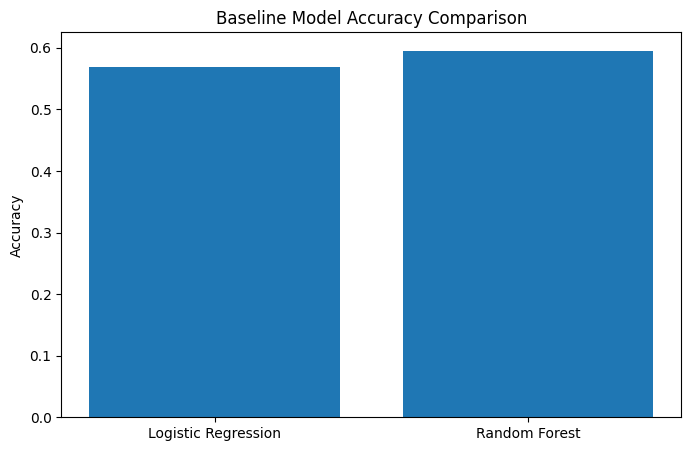

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy Mean"]
)
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy Comparison")
plt.show()

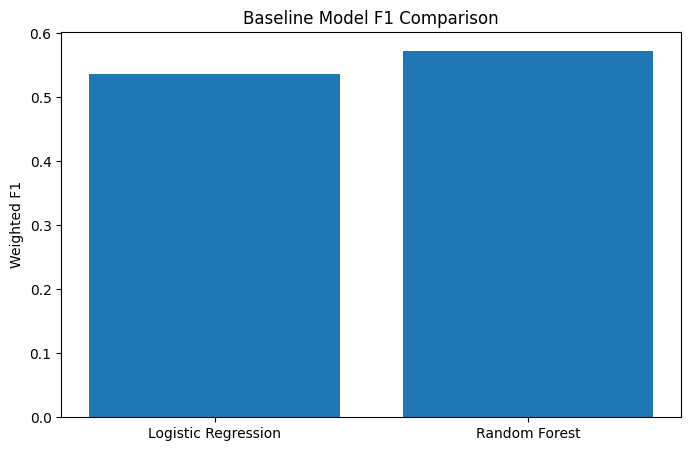

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Mean"]
)
plt.ylabel("Weighted F1")
plt.title("Baseline Model F1 Comparison")

plt.show()

## Sonuçların Yorumu

Random Forest modeli Logistic Regression modelinden daha yüksek Accuracy ve F1 skoru elde etmiştir.

| Model | Accuracy | F1 |
|---------|---------|---------|
| Logistic Regression | 0.57 | 0.54 |
| Random Forest | 0.60 | 0.57 |

Bu sonuç, EEG ve göz hareketi özellikleri arasında doğrusal olmayan ilişkilerin bulunduğunu göstermektedir.

Bu nedenle ileride kullanılacak MLP ve ReLF gibi daha karmaşık modellerin performans artışı sağlaması beklenmektedir.

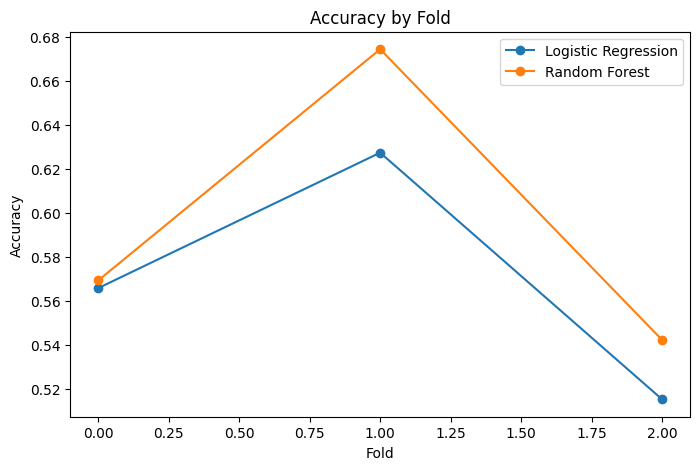

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    logistic_df["fold"],
    logistic_df["accuracy"],
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    rf_df["fold"],
    rf_df["accuracy"],
    marker="o",
    label="Random Forest"
)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy by Fold")

plt.legend()
plt.show()

## Fold Bazında Performans Analizi

Her iki modelde de Fold 1 en yüksek performansı üretirken Fold 2 en düşük performansı üretmiştir.

Benzer davranışın her iki modelde de görülmesi, performans farkının model mimarisinden değil test kliplerinin zorluk seviyesinden kaynaklandığını göstermektedir.

Bu durum bazı video kliplerinin diğerlerine göre daha kolay sınıflandırılabildiğini düşündürmektedir.

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [17]:
from sklearn.ensemble import RandomForestClassifier

from src.models.baseline.feature_loader import (
    load_features_for_split
)

In [18]:
split_path = (
    "D:/ReLF/data/reports/"
    "subject_dependent_split_index.csv"
)

X_train, y_train = load_features_for_split(
    split_index_csv_path=split_path,
    fold=1,
    split="train",
    max_samples=5000
)

X_test, y_test = load_features_for_split(
    split_index_csv_path=split_path,
    fold=1,
    split="test",
    max_samples=2000
)

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[554,   0,   0,  38],
       [ 45, 372,  27,  91],
       [ 21, 186, 300,  37],
       [ 58, 136,  12, 123]])

## Confusion Matrix Analizi

Accuracy metriği modelin genel başarısını göstermektedir.

Ancak hangi duygu sınıflarının birbirleriyle karıştırıldığını görmek için Confusion Matrix kullanılmaktadır.

Bu analiz sayesinde modelin güçlü ve zayıf olduğu duygu sınıfları belirlenebilir.

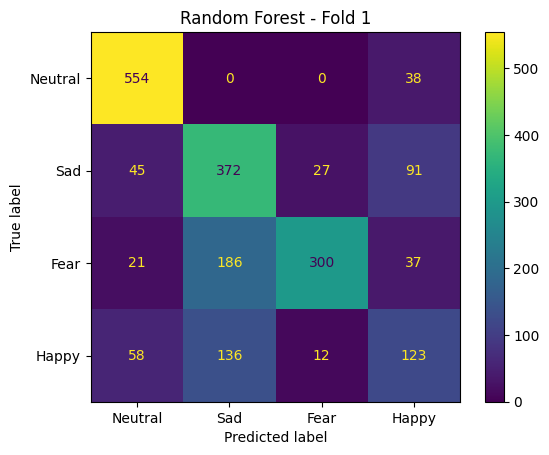

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Neutral",
        "Sad",
        "Fear",
        "Happy"
    ]
)

disp.plot()

plt.title(
    "Random Forest - Fold 1"
)

plt.show()

## Confusion Matrix Yorumu

Random Forest modeli Neutral sınıfını oldukça yüksek doğrulukla sınıflandırmıştır.

Buna karşılık Fear ve Sad sınıfları arasında belirgin bir karışıklık gözlemlenmiştir.

Özellikle Fear örneklerinin önemli bir kısmı Sad olarak tahmin edilmiştir.

Bu durum her iki duygunun benzer nörofizyolojik örüntüler üretmesinden kaynaklanabilir.

Happy sınıfı ise model tarafından en zor öğrenilen duygu olmuştur.

In [22]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_accuracy

array([0.93581081, 0.6953271 , 0.55147059, 0.37386018])

In [23]:
emotion_names = [
    "Neutral",
    "Sad",
    "Fear",
    "Happy"
]

for emotion, score in zip(
    emotion_names,
    class_accuracy
):
    print(
        f"{emotion}: {score:.3f}"
    )

Neutral: 0.936
Sad: 0.695
Fear: 0.551
Happy: 0.374


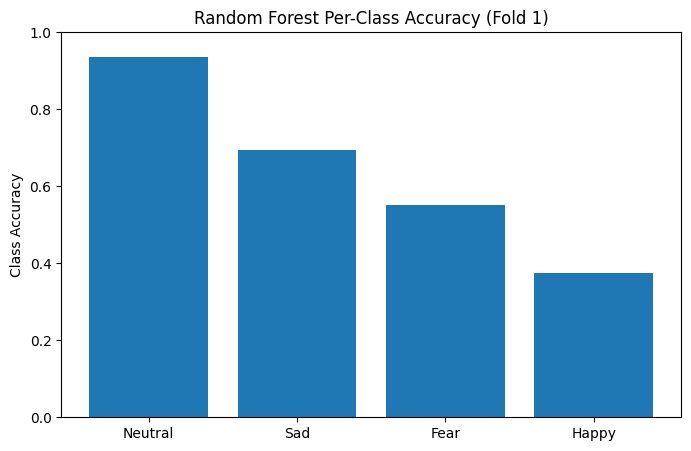

In [24]:
import matplotlib.pyplot as plt

emotion_names = [
    "Neutral",
    "Sad",
    "Fear",
    "Happy"
]

plt.figure(figsize=(8,5))

plt.bar(
    emotion_names,
    class_accuracy
)

plt.ylabel("Class Accuracy")
plt.title(
    "Random Forest Per-Class Accuracy (Fold 1)"
)

plt.ylim(0, 1)

plt.show()

Neutral 0.936
Sad 0.695
Fear 0.551
Happy 0.374

## Duygu Bazında Başarı Analizi

Her duygu sınıfı için ayrı başarı oranları hesaplanmıştır.

Sonuçlar aşağıdaki gibidir:

- Neutral : %93.6
- Sad : %69.5
- Fear : %55.1
- Happy : %37.4

Neutral sınıfı açık ara en başarılı sınıf olmuştur.

Happy sınıfı ise en düşük başarı oranına sahiptir.

Bu durum, mevcut EEG ve göz hareketi özelliklerinin Happy duygusunu ayırt etmekte yetersiz kaldığını göstermektedir.

İleride uygulanacak derin öğrenme modellerinin özellikle Happy ve Fear sınıflarında iyileşme sağlaması beklenmektedir.